<a href="https://colab.research.google.com/github/LarsVoermans/master-thesis-pead/blob/main/XGBboosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#All imports
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight
import shap



In [ ]:
from google.colab import files
uploaded = files.upload()  # er verschijnt een knop om bestanden te kiezen

Saving train_feature_engineered.parquet to train_feature_engineered.parquet
Saving val_feature_engineered.parquet to val_feature_engineered.parquet


In [ ]:
#Loading the dataset
train = pd.read_parquet("train_feature_engineered.parquet")
val = pd.read_parquet("val_feature_engineered.parquet")

In [ ]:
#making 3 class return
# Train
conditions_train = [
    (train['Return'] > 3),
    (train['Return'] >= -3) & (train['Return'] <= 3),
    (train['Return'] < -3)
]

choices = [0, 1, 2]

train['Return_class_3'] = np.select(conditions_train, choices, default=np.nan)


# Validation
conditions_val = [
    (val['Return'] > 3),
    (val['Return'] >= -3) & (val['Return'] <= 3),
    (val['Return'] < -3)
]

val['Return_class_3'] = np.select(conditions_val, choices, default=np.nan)



In [ ]:
#making a return class
target = "Return"

X_train = train.drop(columns=["Return","Return_class","EPS_Estimate","EPS_Actual","Close_Before","Open_After","Return_class_3"])
y_train = train["Return_class_3"]

X_val = val.drop(columns=["Return","Return_class","EPS_Estimate","EPS_Actual","Close_Before","Open_After","Return_class_3"])
y_val = val["Return_class_3"]


In [ ]:
#Dropping colums
drop_cols = [
    'CUSIP',
    'Global Company Key',
    'Historical CRSP PERMNO Link to COMPUSTAT Record',
    'Ticker',
    'Date',
    'EarningsDate',
    'Fiscal year end',
    'Fiscal quarter end',
    'Year',
    'Month'
]

X_train = X_train.drop(columns=[c for c in drop_cols if c in X_train.columns])
X_val = X_val.drop(columns=[c for c in drop_cols if c in X_val.columns])

In [ ]:
# add train and validation
X_all = pd.concat([X_train, X_val], axis=0)
y_all = pd.concat([y_train, y_val], axis=0)

X_all.reset_index(drop=True, inplace=True)
y_all.reset_index(drop=True, inplace=True)

# Stratified K-Fold
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

accuracy_list = []
macro_f1_list = []
fold_reports = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), 1):
    print(f"\n--- Fold {fold} ---")

    X_tr, X_val_fold = X_all.iloc[train_idx], X_all.iloc[val_idx]
    y_tr, y_val_fold = y_all.iloc[train_idx], y_all.iloc[val_idx]

    # XGB Classifier
    xgb_model = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        enable_categorical=True,
        random_state=42
    )

    # Fit
    xgb_model.fit(X_tr, y_tr)

    # Predict
    y_pred = xgb_model.predict(X_val_fold)

    # Scores
    acc = accuracy_score(y_val_fold, y_pred)
    f1 = f1_score(y_val_fold, y_pred, average='macro')
    report = classification_report(y_val_fold, y_pred, output_dict=True)

    accuracy_list.append(acc)
    macro_f1_list.append(f1)
    fold_reports.append(report)

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1:.4f}")
    print("Classification Report:")
    print(classification_report(y_val_fold, y_pred))

# Average scores
print("\n=== Average over all folds ===")
print(f"Average Accuracy: {np.mean(accuracy_list):.4f}")
print(f"Average Macro F1: {np.mean(macro_f1_list):.4f}")

# average classification report
avg_report = {}
classes = y_all.unique()
for c in classes:
    avg_report[c] = {}
    metrics = ['precision', 'recall', 'f1-score', 'support']
    for m in metrics:
        avg_report[c][m] = np.mean([fold_reports[i][str(c)][m] for i in range(n_splits)])
avg_report['macro avg'] = {m: np.mean([fold_reports[i]['macro avg'][m] for i in range(n_splits)]) for m in metrics}
avg_report['weighted avg'] = {m: np.mean([fold_reports[i]['weighted avg'][m] for i in range(n_splits)]) for m in metrics}

print("\n=== Average Classification Report per class ===")
print(pd.DataFrame(avg_report).T)


--- Fold 1 ---
Accuracy: 0.6962
Macro F1: 0.4922
Classification Report:
              precision    recall  f1-score   support

         0.0       0.51      0.31      0.39       411
         1.0       0.74      0.93      0.82      1474
         2.0       0.49      0.18      0.27       370

    accuracy                           0.70      2255
   macro avg       0.58      0.48      0.49      2255
weighted avg       0.65      0.70      0.65      2255


--- Fold 2 ---
Accuracy: 0.6943
Macro F1: 0.4912
Classification Report:
              precision    recall  f1-score   support

         0.0       0.53      0.31      0.39       412
         1.0       0.74      0.93      0.82      1473
         2.0       0.45      0.19      0.26       369

    accuracy                           0.69      2254
   macro avg       0.57      0.47      0.49      2254
weighted avg       0.65      0.69      0.65      2254


--- Fold 3 ---
Accuracy: 0.6952
Macro F1: 0.4961
Classification Report:
              preci

Top 20 Features - XGBoost (gebaseerd op Gain):
                                              Feature       gain  weight
0                                  Book/Market_Regime  23.166260   116.0
1                                   Price/Book_Regime  22.776749    74.0
2                                        Surprise_Pct  12.785983   423.0
3   Price/Operating Earnings (Basic, Excl. EI)_Regime  11.914400    79.0
4                           Gross Profit/Total Assets  10.882664   121.0
5                      P/E (Diluted, Incl. EI)_Regime  10.784166    88.0
6   Price/Operating Earnings (Diluted, Excl. EI)_R...  10.641223    76.0
7              Pre-tax Return on Total Earning Assets  10.368549   164.0
8                               Dividend Yield_Regime  10.025991   185.0
9                              Price/Cash flow_Regime   7.285032   123.0
10                    Interest/Average Long-term Debt   6.933988   191.0
11                          Sales/Stockholders Equity   6.818924   237.0
12  

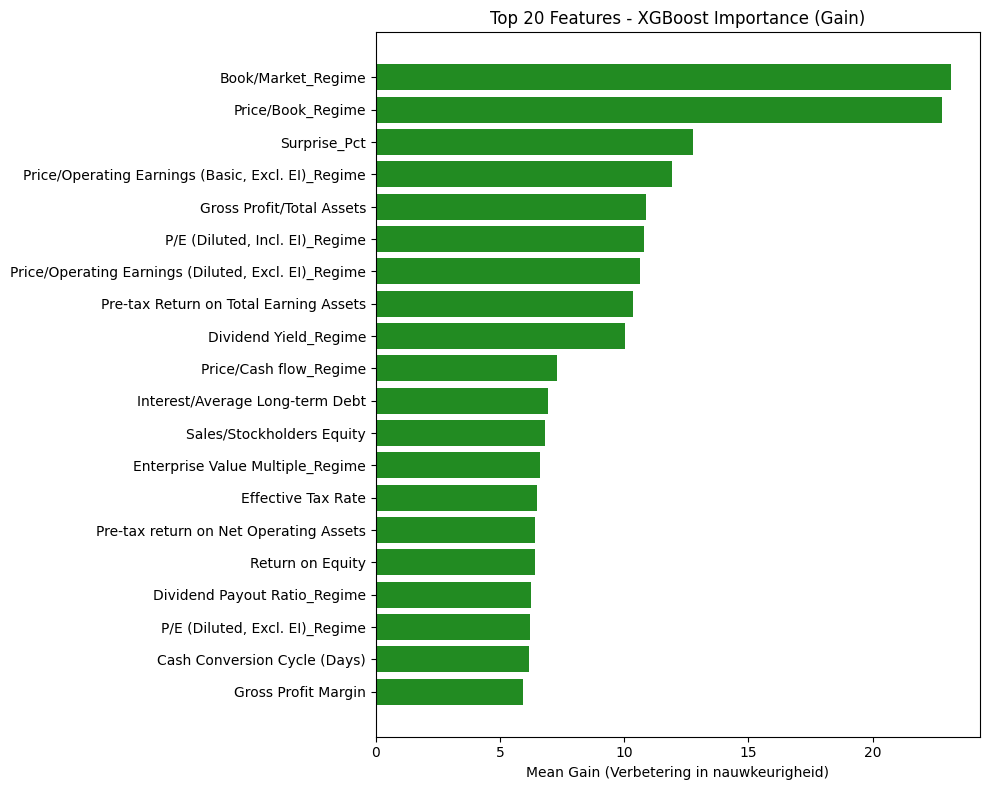

In [ ]:
#Feature Importance
importance_types = ['gain', 'weight']
xgb_importances = pd.DataFrame({'Feature': X_all.columns})

for imp_type in importance_types:
    scores = xgb_model.get_booster().get_score(importance_type=imp_type)
    xgb_importances[imp_type] = xgb_importances['Feature'].map(scores).fillna(0)

xgb_importances = xgb_importances.sort_values(by='gain', ascending=False).reset_index(drop=True)

# Print top 20
print("Top 20 Features - XGBoost (gebaseerd op Gain):")
print("="*50)
print(xgb_importances[['Feature', 'gain', 'weight']].head(20))

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.barh(xgb_importances['Feature'][:20], xgb_importances['gain'][:20], color='forestgreen')
plt.gca().invert_yaxis()
plt.title('Top 20 Features - XGBoost Importance (Gain)')
plt.xlabel('Mean Gain (Verbetering in nauwkeurigheid)')
plt.tight_layout()
plt.show()

In [ ]:
#Looking at the most important features and there interaction with other features.
booster = xgb_model.get_booster()
tree_df = booster.trees_to_dataframe()

#suprise percentage
target_feature = 'Surprise_Pct'
interactions = {}

for tree_id in tree_df['Tree'].unique():
    subset = tree_df[tree_df['Tree'] == tree_id]

    surprise_nodes = subset[subset['Feature'] == target_feature]

    for _, node in surprise_nodes.iterrows():
        children_ids = [node['Yes'], node['No']]

        for child_id in children_ids:
            child_row = subset[subset['ID'] == child_id]
            if not child_row.empty:
                child_feature = child_row['Feature'].values[0]

                if child_feature != 'Leaf' and child_feature != target_feature:
                    interactions[child_feature] = interactions.get(child_feature, 0) + 1

interaction_df = pd.DataFrame(list(interactions.items()), columns=['Feature', 'Interaction_Count'])
interaction_df = interaction_df.sort_values(by='Interaction_Count', ascending=False).reset_index(drop=True)

print(f"Top Features die samenwerken met {target_feature}:")
print("="*50)
print(interaction_df.head(15))


#Looking at the most important features and there interaction with other features.
booster = xgb_model.get_booster()
tree_df = booster.trees_to_dataframe()

#suprise percentage
target_feature = 'Book/Market_Regime'
interactions = {}

for tree_id in tree_df['Tree'].unique():
    subset = tree_df[tree_df['Tree'] == tree_id]

    surprise_nodes = subset[subset['Feature'] == target_feature]

    for _, node in surprise_nodes.iterrows():
        children_ids = [node['Yes'], node['No']]

        for child_id in children_ids:
            child_row = subset[subset['ID'] == child_id]
            if not child_row.empty:
                child_feature = child_row['Feature'].values[0]

                if child_feature != 'Leaf' and child_feature != target_feature:
                    interactions[child_feature] = interactions.get(child_feature, 0) + 1

interaction_df = pd.DataFrame(list(interactions.items()), columns=['Feature', 'Interaction_Count'])
interaction_df = interaction_df.sort_values(by='Interaction_Count', ascending=False).reset_index(drop=True)

print(f"Top Features die samenwerken met {target_feature}:")
print("="*50)
print(interaction_df.head(15))


#Looking at the most important features and there interaction with other features.
booster = xgb_model.get_booster()
tree_df = booster.trees_to_dataframe()

#suprise percentage
target_feature = 'Price/Book_Regime'
interactions = {}

for tree_id in tree_df['Tree'].unique():
    subset = tree_df[tree_df['Tree'] == tree_id]

    surprise_nodes = subset[subset['Feature'] == target_feature]

    for _, node in surprise_nodes.iterrows():
        children_ids = [node['Yes'], node['No']]

        for child_id in children_ids:
            child_row = subset[subset['ID'] == child_id]
            if not child_row.empty:
                child_feature = child_row['Feature'].values[0]

                if child_feature != 'Leaf' and child_feature != target_feature:
                    interactions[child_feature] = interactions.get(child_feature, 0) + 1

interaction_df = pd.DataFrame(list(interactions.items()), columns=['Feature', 'Interaction_Count'])
interaction_df = interaction_df.sort_values(by='Interaction_Count', ascending=False).reset_index(drop=True)

print(f"Top Features die samenwerken met {target_feature}:")
print("="*50)
print(interaction_df.head(15))



#Looking at the most important features and there interaction with other features.
booster = xgb_model.get_booster()
tree_df = booster.trees_to_dataframe()

#suprise percentage
target_feature = 'Price/Operating Earnings (Basic, Excl. EI)_Regime'
interactions = {}

for tree_id in tree_df['Tree'].unique():
    subset = tree_df[tree_df['Tree'] == tree_id]

    surprise_nodes = subset[subset['Feature'] == target_feature]

    for _, node in surprise_nodes.iterrows():
        children_ids = [node['Yes'], node['No']]

        for child_id in children_ids:
            child_row = subset[subset['ID'] == child_id]
            if not child_row.empty:
                child_feature = child_row['Feature'].values[0]

                if child_feature != 'Leaf' and child_feature != target_feature:
                    interactions[child_feature] = interactions.get(child_feature, 0) + 1

interaction_df = pd.DataFrame(list(interactions.items()), columns=['Feature', 'Interaction_Count'])
interaction_df = interaction_df.sort_values(by='Interaction_Count', ascending=False).reset_index(drop=True)

print(f"Top Features die samenwerken met {target_feature}:")
print("="*50)
print(interaction_df.head(15))



#Looking at the most important features and there interaction with other features.
booster = xgb_model.get_booster()
tree_df = booster.trees_to_dataframe()

#suprise percentage
target_feature = 'Gross Profit/Total Assets'
interactions = {}

for tree_id in tree_df['Tree'].unique():
    subset = tree_df[tree_df['Tree'] == tree_id]

    surprise_nodes = subset[subset['Feature'] == target_feature]

    for _, node in surprise_nodes.iterrows():
        children_ids = [node['Yes'], node['No']]

        for child_id in children_ids:
            child_row = subset[subset['ID'] == child_id]
            if not child_row.empty:
                child_feature = child_row['Feature'].values[0]

                if child_feature != 'Leaf' and child_feature != target_feature:
                    interactions[child_feature] = interactions.get(child_feature, 0) + 1

interaction_df = pd.DataFrame(list(interactions.items()), columns=['Feature', 'Interaction_Count'])
interaction_df = interaction_df.sort_values(by='Interaction_Count', ascending=False).reset_index(drop=True)

print(f"Top Features die samenwerken met {target_feature}:")
print("="*50)
print(interaction_df.head(15))




#Looking at the most important features and there interaction with other features.
booster = xgb_model.get_booster()
tree_df = booster.trees_to_dataframe()

#suprise percentage
target_feature = 'P/E (Diluted, Incl. EI)_Regime'
interactions = {}

for tree_id in tree_df['Tree'].unique():
    subset = tree_df[tree_df['Tree'] == tree_id]

    surprise_nodes = subset[subset['Feature'] == target_feature]

    for _, node in surprise_nodes.iterrows():
        children_ids = [node['Yes'], node['No']]

        for child_id in children_ids:
            child_row = subset[subset['ID'] == child_id]
            if not child_row.empty:
                child_feature = child_row['Feature'].values[0]

                if child_feature != 'Leaf' and child_feature != target_feature:
                    interactions[child_feature] = interactions.get(child_feature, 0) + 1

interaction_df = pd.DataFrame(list(interactions.items()), columns=['Feature', 'Interaction_Count'])
interaction_df = interaction_df.sort_values(by='Interaction_Count', ascending=False).reset_index(drop=True)

print(f"Top Features die samenwerken met {target_feature}:")
print("="*50)
print(interaction_df.head(15))




#Looking at the most important features and there interaction with other features.
booster = xgb_model.get_booster()
tree_df = booster.trees_to_dataframe()

#suprise percentage
target_feature = 'Price/Operating Earnings (Diluted, Excl. EI)_Regime'
interactions = {}

for tree_id in tree_df['Tree'].unique():
    subset = tree_df[tree_df['Tree'] == tree_id]

    surprise_nodes = subset[subset['Feature'] == target_feature]

    for _, node in surprise_nodes.iterrows():
        children_ids = [node['Yes'], node['No']]

        for child_id in children_ids:
            child_row = subset[subset['ID'] == child_id]
            if not child_row.empty:
                child_feature = child_row['Feature'].values[0]

                if child_feature != 'Leaf' and child_feature != target_feature:
                    interactions[child_feature] = interactions.get(child_feature, 0) + 1

interaction_df = pd.DataFrame(list(interactions.items()), columns=['Feature', 'Interaction_Count'])
interaction_df = interaction_df.sort_values(by='Interaction_Count', ascending=False).reset_index(drop=True)

print(f"Top Features die samenwerken met {target_feature}:")
print("="*50)
print(interaction_df.head(15))


#Looking at the most important features and there interaction with other features.
booster = xgb_model.get_booster()
tree_df = booster.trees_to_dataframe()

#suprise percentage
target_feature = 'Pre-tax Return on Total Earning Assets'
interactions = {}

for tree_id in tree_df['Tree'].unique():
    subset = tree_df[tree_df['Tree'] == tree_id]

    surprise_nodes = subset[subset['Feature'] == target_feature]

    for _, node in surprise_nodes.iterrows():
        children_ids = [node['Yes'], node['No']]

        for child_id in children_ids:
            child_row = subset[subset['ID'] == child_id]
            if not child_row.empty:
                child_feature = child_row['Feature'].values[0]

                if child_feature != 'Leaf' and child_feature != target_feature:
                    interactions[child_feature] = interactions.get(child_feature, 0) + 1

interaction_df = pd.DataFrame(list(interactions.items()), columns=['Feature', 'Interaction_Count'])
interaction_df = interaction_df.sort_values(by='Interaction_Count', ascending=False).reset_index(drop=True)

print(f"Top Features die samenwerken met {target_feature}:")
print("="*50)
print(interaction_df.head(15))



#Looking at the most important features and there interaction with other features.
booster = xgb_model.get_booster()
tree_df = booster.trees_to_dataframe()

#suprise percentage
target_feature = 'Dividend Yield_Regime'
interactions = {}

for tree_id in tree_df['Tree'].unique():
    subset = tree_df[tree_df['Tree'] == tree_id]

    surprise_nodes = subset[subset['Feature'] == target_feature]

    for _, node in surprise_nodes.iterrows():
        children_ids = [node['Yes'], node['No']]

        for child_id in children_ids:
            child_row = subset[subset['ID'] == child_id]
            if not child_row.empty:
                child_feature = child_row['Feature'].values[0]

                if child_feature != 'Leaf' and child_feature != target_feature:
                    interactions[child_feature] = interactions.get(child_feature, 0) + 1

interaction_df = pd.DataFrame(list(interactions.items()), columns=['Feature', 'Interaction_Count'])
interaction_df = interaction_df.sort_values(by='Interaction_Count', ascending=False).reset_index(drop=True)

print(f"Top Features die samenwerken met {target_feature}:")
print("="*50)
print(interaction_df.head(15))

Top Features die samenwerken met Surprise_Pct:
                                              Feature  Interaction_Count
0                               Dividend Yield_Regime                 41
1              Pre-tax Return on Total Earning Assets                 21
2                              Price/Cash flow_Regime                 20
3                                 Gross Profit Margin                 19
4                    Enterprise Value Multiple_Regime                 19
5                     Interest/Average Long-term Debt                 18
6                                  Inventory Turnover                 16
7                      Research and Development/Sales                 16
8   Price/Operating Earnings (Diluted, Excl. EI)_R...                 15
9                                   Price/Book_Regime                 14
10                         Receivables/Current Assets                 13
11                        After-tax Interest Coverage                 12
12  

In [ ]:
# 29 core features
top_29_features = [
    "Surprise_Pct",
    "Sales/Stockholders Equity",
    "Payables Turnover",
    "Total Debt/EBITDA",
    "Sales/Stockholders Equity_QoQ",
    "Total Liabilities/Total Tangible Assets",
    "Long-term Debt/Book Equity",
    "Current Ratio",
    "Sales/Invested Capital",
    "Return on Equity",
    "Book/Market_Regime",
    "Price/Book_Regime",
    "Price/Operating Earnings (Basic, Excl. EI)_Regime",
    "Gross Profit/Total Assets",
    "P/E (Diluted, Incl. EI)_Regime",
    "Price/Operating Earnings (Diluted, Excl. EI)_Regime",
    "Pre-tax Return on Total Earning Assets",
    "Dividend Yield_Regime",
    "Effective Tax Rate",
    "Gross Profit Margin",
    "Interest/Average Long-term Debt",
    "Enterprise Value Multiple_Regime",
    "Inventory Turnover",
    "Receivables/Current Assets",
    "Cash Conversion Cycle (Days)",
    "Total Debt/Capital",
    "Interest Coverage Ratio",
    "Receivables Turnover",
    "Asset Turnover"
]

#Making new variable
X_train_29 = X_train[top_29_features].copy()
X_val_29 = X_val[top_29_features].copy()

In [ ]:

# ---------------------------------------------------------
# 29 Features train model
# ---------------------------------------------------------
X_all_29 = pd.concat([X_train_29, X_val_29], axis=0).copy()
y_all_29 = pd.concat([y_train, y_val], axis=0).copy()

X_all_29.reset_index(drop=True, inplace=True)
y_all_29.reset_index(drop=True, inplace=True)

# ---------------------------------------------------------
# 2. Stratified K-Fold setup for model 29
# ---------------------------------------------------------
skf_29 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_list_29 = []
macro_f1_list_29 = []
fold_reports_29 = []

for fold, (train_idx, val_idx) in enumerate(skf_29.split(X_all_29, y_all_29), 1):
    print(f"\n--- XGBoost Model 29 | Fold {fold} ---")

    X_tr_29, X_val_fold_29 = X_all_29.iloc[train_idx], X_all_29.iloc[val_idx]
    y_tr_29, y_val_fold_29 = y_all_29.iloc[train_idx], y_all_29.iloc[val_idx]

    # XGB Classifier
    xgb_model_29 = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        enable_categorical=True,
        random_state=42
    )

    # Fit
    xgb_model_29.fit(X_tr_29, y_tr_29)

    # Predict
    y_pred_29 = xgb_model_29.predict(X_val_fold_29)


    acc_29 = accuracy_score(y_val_fold_29, y_pred_29)
    f1_29 = f1_score(y_val_fold_29, y_pred_29, average='macro')
    report_29 = classification_report(y_val_fold_29, y_pred_29, output_dict=True)


    accuracy_list_29.append(acc_29)
    macro_f1_list_29.append(f1_29)
    fold_reports_29.append(report_29)

    print(f"Accuracy: {acc_29:.4f} | Macro F1: {f1_29:.4f}")

# ---------------------------------------------------------
# 3. Average results for Model 29
# ---------------------------------------------------------
print("\n" + "="*50)
print("=== AVERAGE RESULTS XGBOOST MODEL 29 (BASELINE) ===")
print("="*50)
avg_acc_29 = np.mean(accuracy_list_29)
avg_f1_29 = np.mean(macro_f1_list_29)
print(f"Average Accuracy 29: {avg_acc_29:.4f}")
print(f"Average Macro F1 29: {avg_f1_29:.4f}")

avg_report_29 = {}
classes_29 = y_all_29.unique()
metrics = ['precision', 'recall', 'f1-score', 'support']

for c in classes_29:
    avg_report_29[str(c)] = {}
    for m in metrics:
        avg_report_29[str(c)][m] = np.mean([fold_reports_29[i][str(c)][m] for i in range(5)])

for label in ['macro avg', 'weighted avg']:
    avg_report_29[label] = {}
    for m in metrics:
        avg_report_29[label][m] = np.mean([fold_reports_29[i][label][m] for i in range(5)])

df_final_report_29 = pd.DataFrame(avg_report_29).T
print("\n=== Average Classification Report Model 29 ===")
print(df_final_report_29)


--- XGBoost Model 29 | Fold 1 ---
Accuracy: 0.6922 | Macro F1: 0.4958

--- XGBoost Model 29 | Fold 2 ---
Accuracy: 0.6961 | Macro F1: 0.4980

--- XGBoost Model 29 | Fold 3 ---
Accuracy: 0.6886 | Macro F1: 0.4907

--- XGBoost Model 29 | Fold 4 ---
Accuracy: 0.6917 | Macro F1: 0.5049

--- XGBoost Model 29 | Fold 5 ---
Accuracy: 0.7005 | Macro F1: 0.5032

=== AVERAGE RESULTS XGBOOST MODEL 29 (BASELINE) ===
Average Accuracy 29: 0.6938
Average Macro F1 29: 0.4985

=== Average Classification Report Model 29 ===
              precision    recall  f1-score  support
1.0            0.742270  0.922346  0.822566   1473.2
0.0            0.491784  0.302865  0.374702    411.4
2.0            0.472889  0.218059  0.298280    369.6
macro avg      0.568981  0.481090  0.498516   2254.2
weighted avg   0.652398  0.693816  0.654872   2254.2



--- Genereren SHAP Summary Plot (Bar) ---


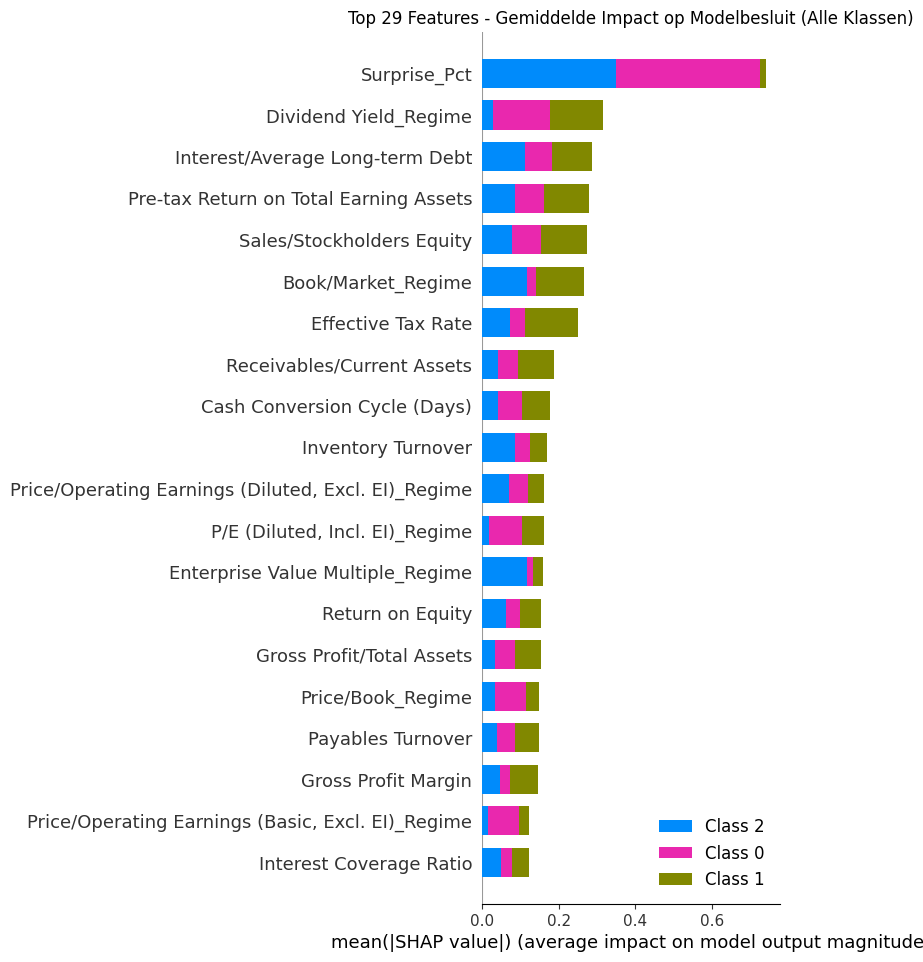


--- Genereren SHAP Beeswarm Plot voor Klasse 0.0 (Buy / Winst > 3%) ---


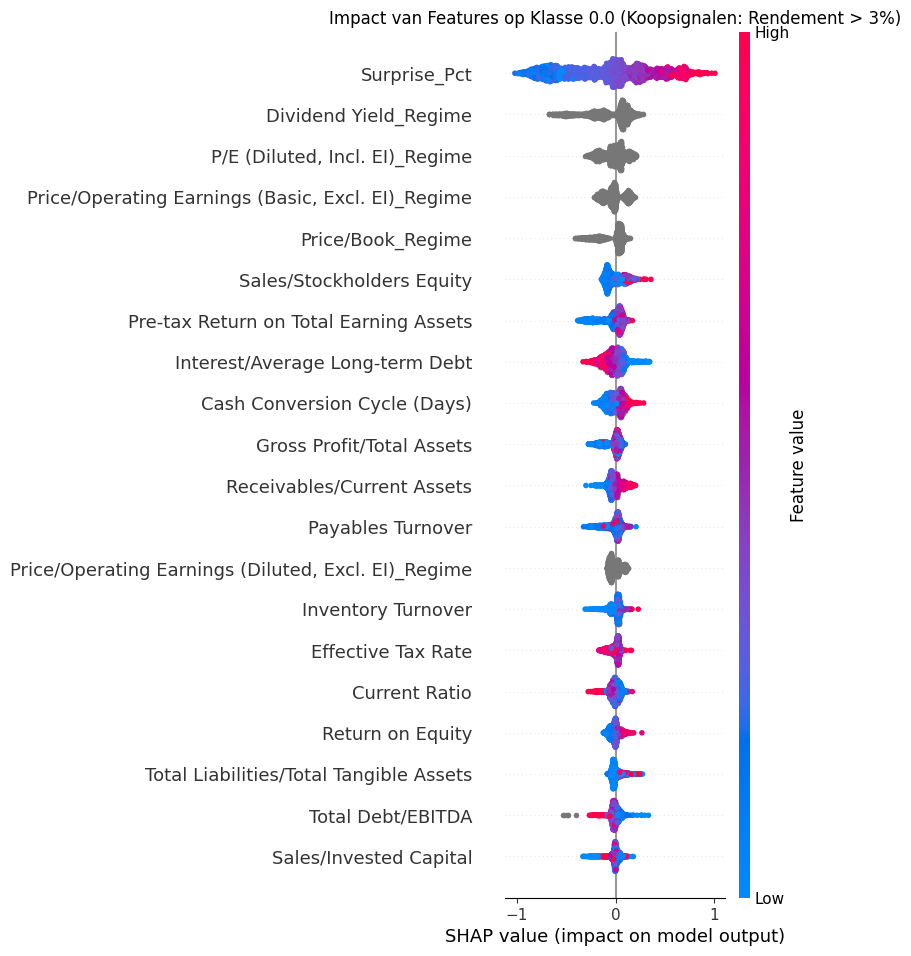

In [ ]:


# SHAP analyses
explainer = shap.TreeExplainer(xgb_model_29)

shap_values = explainer.shap_values(X_val_fold_29)


print("\n--- Genereren SHAP Summary Plot (Bar) ---")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val_fold_29, plot_type="bar", show=False)
plt.title("Top 29 Features - Gemiddelde Impact op Modelbesluit (Alle Klassen)")
plt.show()


print("\n--- Genereren SHAP Beeswarm Plot voor Klasse 0.0 (Buy / Winst > 3%) ---")

try:
    target_shap_values = shap_values[0]

    if not isinstance(shap_values, list) and len(shap_values.shape) == 3:
        target_shap_values = shap_values[:, :, 0]

    plt.figure(figsize=(12, 10))
    shap.summary_plot(target_shap_values, X_val_fold_29, show=False)
    plt.title("Impact van Features op Klasse 0.0 (Koopsignalen: Rendement > 3%)")
    plt.show()

except Exception as e:
    print(f"Beeswarm mislukt door: {e}")
    if isinstance(shap_values, list):
        print(f"shap_values is een lijst met {len(shap_values)} elementen.")
    else:
        print(f"Vorm van shap_values array: {shap_values.shape}")

In [ ]:
# Hyperparameter tuning for 29 features
sample_weights_29 = compute_sample_weight(class_weight='balanced', y=y_all_29)

xgb_base_29 = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    random_state=42,
    enable_categorical=True,
    eval_metric='mlogloss'
)

param_grid_29 = {
    'n_estimators': [300, 500, 700],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [1, 5, 10, 20],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.5, 1]
}


xgb_search_29 = RandomizedSearchCV(
    estimator=xgb_base_29,
    param_distributions=param_grid_29,
    n_iter=25,
    cv=5,
    scoring='f1_macro',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Start Hyperparameter Tuning voor Model 29...")
xgb_search_29.fit(X_all_29, y_all_29, sample_weight=sample_weights_29)


best_params_29 = xgb_search_29.best_params_

print("\n" + "="*50)
print("GEBRUIK DEZE INSTELLINGEN IN JE XGB_MODEL_29 BLOK:")
print("="*50)
for param, value in best_params_29.items():
    print(f"{param:18}: {value}")
print("="*50)
print(f"Beste Macro F1 Score tijdens tuning: {xgb_search_29.best_score_:.4f}")
print("="*50)

Start Hyperparameter Tuning voor Model 29...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

GEBRUIK DEZE INSTELLINGEN IN JE XGB_MODEL_29 BLOK:
subsample         : 0.9
n_estimators      : 500
min_child_weight  : 20
max_depth         : 4
learning_rate     : 0.01
gamma             : 1
colsample_bytree  : 0.8
Beste Macro F1 Score tijdens tuning: 0.4822


In [ ]:
#hyperparameter settings
X_all_29 = pd.concat([X_train_29, X_val_29], axis=0).copy()
y_all_29 = pd.concat([y_train, y_val], axis=0).copy()

X_all_29.reset_index(drop=True, inplace=True)
y_all_29.reset_index(drop=True, inplace=True)

# ---------------------------------------------------------
# 2. Stratified K-Fold setup
# ---------------------------------------------------------
skf_29 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_list_29 = []
macro_f1_list_29 = []
fold_reports_29 = []

# ---------------------------------------------------------
# 3. Training Loop
# ---------------------------------------------------------
for fold, (train_idx, val_idx) in enumerate(skf_29.split(X_all_29, y_all_29), 1):
    print(f"\n--- XGBoost Model 29 | Fold {fold} ---")

    X_tr_29, X_val_fold_29 = X_all_29.iloc[train_idx], X_all_29.iloc[val_idx]
    y_tr_29, y_val_fold_29 = y_all_29.iloc[train_idx], y_all_29.iloc[val_idx]

    sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_tr_29
    )

    # XGBoost model (tuned settings)
    xgb_model_29 = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        subsample=0.9,
        n_estimators=500,
        min_child_weight=20,
        max_depth=4,
        learning_rate=0.01,
        gamma=1,
        colsample_bytree=0.8,
        enable_categorical=True,
        random_state=42
    )

    xgb_model_29.fit(
        X_tr_29,
        y_tr_29,
        sample_weight=sample_weights
    )

    # Predict
    y_pred_29 = xgb_model_29.predict(X_val_fold_29)

    acc_29 = accuracy_score(y_val_fold_29, y_pred_29)
    f1_29 = f1_score(y_val_fold_29, y_pred_29, average='macro')
    report_dict = classification_report(y_val_fold_29, y_pred_29, output_dict=True)

    accuracy_list_29.append(acc_29)
    macro_f1_list_29.append(f1_29)
    fold_reports_29.append(report_dict)

    print(f"Accuracy: {acc_29:.4f} | Macro F1: {f1_29:.4f}")

# ---------------------------------------------------------
# 4. Final CV Results
# ---------------------------------------------------------
print("\n" + "="*50)
print("AVERAGE RESULTS XGBOOST MODEL 29")
print("="*50)
print(f"Average Accuracy: {np.mean(accuracy_list_29):.4f}")
print(f"Average Macro F1: {np.mean(macro_f1_list_29):.4f}")

# ---------------------------------------------------------
# 5. Average Classification Report
# ---------------------------------------------------------
avg_report_29 = {}

for label in fold_reports_29[0].keys():
    if label == "accuracy":
        avg_report_29[label] = np.mean([r[label] for r in fold_reports_29])
        continue

    avg_report_29[label] = {}
    for metric in fold_reports_29[0][label].keys():
        avg_report_29[label][metric] = np.mean([r[label][metric] for r in fold_reports_29])

df_report_29 = pd.DataFrame(avg_report_29).T
column_order = ['precision', 'recall', 'f1-score', 'support']
df_report_29 = df_report_29.reindex(columns=column_order)

print("\nAverage Classification Report Model 29 (Across all Folds):")
print(df_report_29)


--- XGBoost Model 29 | Fold 1 ---
Accuracy: 0.5800 | Macro F1: 0.5212

--- XGBoost Model 29 | Fold 2 ---
Accuracy: 0.5812 | Macro F1: 0.5206

--- XGBoost Model 29 | Fold 3 ---
Accuracy: 0.5714 | Macro F1: 0.5044

--- XGBoost Model 29 | Fold 4 ---
Accuracy: 0.5909 | Macro F1: 0.5271

--- XGBoost Model 29 | Fold 5 ---
Accuracy: 0.5958 | Macro F1: 0.5357

AVERAGE RESULTS XGBOOST MODEL 29
Average Accuracy: 0.5839
Average Macro F1: 0.5218

Average Classification Report Model 29 (Across all Folds):
              precision    recall  f1-score      support
0.0            0.353766  0.605730  0.446549   411.400000
1.0            0.865377  0.598562  0.707616  1473.200000
2.0            0.348835  0.501047  0.411275   369.600000
accuracy       0.583888  0.583888  0.583888     0.583888
macro avg      0.522660  0.568446  0.521813  2254.200000
weighted avg   0.687317  0.583888  0.611386  2254.200000


Testing phase

In [ ]:
from google.colab import files
uploaded = files.upload()  # er verschijnt een knop om bestanden te kiezen

Saving test_feature_engineered.parquet to test_feature_engineered.parquet


In [ ]:
test = pd.read_parquet("test_feature_engineered.parquet")

In [ ]:
#making 3 class return
# test
conditions_test = [
    (test['Return'] > 3),
    (test['Return'] >= -3) & (test['Return'] <= 3),
    (test['Return'] < -3)
]

choices = [0, 1, 2]

test['Return_class_3'] = np.select(conditions_test, choices, default=np.nan)

#making a return class
target = "Return"

X_test = test.drop(columns=["Return","Return_class","EPS_Estimate","EPS_Actual","Close_Before","Open_After","Return_class_3"])
y_test = test["Return_class_3"]

#Dropping colums
drop_cols = [
    'CUSIP',
    'Global Company Key',
    'Historical CRSP PERMNO Link to COMPUSTAT Record',
    'Ticker',
    'Date',
    'EarningsDate',
    'Fiscal year end',
    'Fiscal quarter end',
    'Year',
    'Month'
]

X_test = X_test.drop(columns=[c for c in drop_cols if c in X_test.columns])

# 29 core features
top_29_features = [
    "Surprise_Pct",
    "Sales/Stockholders Equity",
    "Payables Turnover",
    "Total Debt/EBITDA",
    "Sales/Stockholders Equity_QoQ",
    "Total Liabilities/Total Tangible Assets",
    "Long-term Debt/Book Equity",
    "Current Ratio",
    "Sales/Invested Capital",
    "Return on Equity",
    "Book/Market_Regime",
    "Price/Book_Regime",
    "Price/Operating Earnings (Basic, Excl. EI)_Regime",
    "Gross Profit/Total Assets",
    "P/E (Diluted, Incl. EI)_Regime",
    "Price/Operating Earnings (Diluted, Excl. EI)_Regime",
    "Pre-tax Return on Total Earning Assets",
    "Dividend Yield_Regime",
    "Effective Tax Rate",
    "Gross Profit Margin",
    "Interest/Average Long-term Debt",
    "Enterprise Value Multiple_Regime",
    "Inventory Turnover",
    "Receivables/Current Assets",
    "Cash Conversion Cycle (Days)",
    "Total Debt/Capital",
    "Interest Coverage Ratio",
    "Receivables Turnover",
    "Asset Turnover"
]

#Making new variable
X_test_29 = X_test[top_29_features].copy()

In [ ]:
# ---------------------------------------------------------
# 1. Testing model on the test set for 29 features set
# ---------------------------------------------------------

X_test_final = X_test_29.copy()

X_test_final.columns = X_test_final.columns.str.replace(r'[^A-Za-z0-9_]+', '_', regex=True)
X_all_29.columns = X_all_29.columns.str.replace(r'[^A-Za-z0-9_]+', '_', regex=True)

# ---------------------------------------------------------
# 2. Train the model
# ---------------------------------------------------------
print("Training final model on all development data...")

xgb_final_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    enable_categorical=True,
    random_state=42
)

xgb_final_model.fit(X_all_29, y_all_29)

# ---------------------------------------------------------
# 3. Predicting
# ---------------------------------------------------------
y_test_pred = xgb_final_model.predict(X_test_final)
y_test_proba = xgb_final_model.predict_proba(X_test_final) # Belangrijk voor backtest!

# ---------------------------------------------------------
# 4. Loading results
# ---------------------------------------------------------
print("\n" + "="*50)
print("=== FINAL RESULTS ON TEST SET (UNSEEN DATA) ===")
print("="*50)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro F1: {test_f1:.4f}")
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))

Training final model on all development data...

=== FINAL RESULTS ON TEST SET (UNSEEN DATA) ===
Test Accuracy: 0.5132
Test Macro F1: 0.4233

Test Classification Report:
              precision    recall  f1-score   support

         0.0       0.56      0.21      0.31       400
         1.0       0.50      0.93      0.65       540
         2.0       0.56      0.22      0.31       352

    accuracy                           0.51      1292
   macro avg       0.54      0.45      0.42      1292
weighted avg       0.53      0.51      0.45      1292



In [ ]:
# ---------------------------------------------------------
# 1. Testing model on the test set for 29 features set with sample weights and tuning settings
# ---------------------------------------------------------
X_test_final = X_test_29.copy()

X_test_final.columns = X_test_final.columns.str.replace(r'[^A-Za-z0-9_]+', '_', regex=True)
X_all_29.columns = X_all_29.columns.str.replace(r'[^A-Za-z0-9_]+', '_', regex=True)

# ---------------------------------------------------------
# 2. Sample Weights
# ---------------------------------------------------------

sample_weights_29 = compute_sample_weight(class_weight='balanced', y=y_all_29)

# ---------------------------------------------------------
# 3. Train Tuned XGBoost Model
# ---------------------------------------------------------
print("Training final Tuned XGBoost model on all development data...")

xgb_final_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=500,        # Update
    max_depth=4,             # Update
    learning_rate=0.01,      # Update
    subsample=0.9,           # Update
    colsample_bytree=0.8,    # Update
    min_child_weight=20,     # Added
    gamma=1,                 # Added
    enable_categorical=True,
    random_state=42,
    n_jobs=-1
)

xgb_final_model.fit(X_all_29, y_all_29, sample_weight=sample_weights_29)

# ---------------------------------------------------------
# 4. Predicting on test set
# ---------------------------------------------------------
y_test_pred = xgb_final_model.predict(X_test_final)
y_test_proba = xgb_final_model.predict_proba(X_test_final)

# ---------------------------------------------------------
# 5. Results
# ---------------------------------------------------------
print("\n" + "="*50)
print("=== FINAL TUNED XGBOOST RESULTS ON TEST SET ===")
print("="*50)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro F1: {test_f1:.4f}")
print("\nTest Classification Report (Tuned XGBoost):")
print(classification_report(y_test, y_test_pred))

Training final Tuned XGBoost model on all development data...

=== FINAL TUNED XGBOOST RESULTS ON TEST SET ===
Test Accuracy: 0.5673
Test Macro F1: 0.5584

Test Classification Report (Tuned XGBoost):
              precision    recall  f1-score   support

         0.0       0.51      0.53      0.52       400
         1.0       0.69      0.62      0.65       540
         2.0       0.47      0.54      0.50       352

    accuracy                           0.57      1292
   macro avg       0.56      0.56      0.56      1292
weighted avg       0.58      0.57      0.57      1292

